# 🌀 Énigmes & Merveilles de Rudy Rucker

*Un notebook démo pour matheux, dans l'esprit de Rudy Rucker — mathématicien, informaticien et romancier
de science-fiction, arrière-arrière-petit-fils de Hegel, auteur de *The Fourth Dimension*, *Infinity and
the Mind*, *Mind Tools*, du logiciel d'automates cellulaires *CelLab*, et de la série de romans
*Continuum* explorant les dimensions supérieures et l'infini.*

Ce notebook regroupe **8 énigmes / explorations** directement issues (ou inspirées) de ses livres et
logiciels, dans la continuité de la démo JupyterLab entamée avec Gardner, Pickover, Stewart, Delahaye et
du Sautoy — même recette : calcul, texte, visualisation et interactivité réunis dans un seul document.

**Sommaire**

1. [L'hypercube (tesseract) : rotation en 4 dimensions](#1)
2. [L'infini de Cantor : l'argument diagonal](#2)
3. [Automate cellulaire « Brian's Brain »](#3)
4. [Le ruban de Möbius et la bouteille de Klein](#4)
5. [Le « gnarl » : les classes de complexité de Wolfram](#5)
6. [La projection stéréographique](#6)
7. [Vie artificielle : essaims et comportement émergent (boids)](#7)
8. [Le tapis de Sierpinski et l'éponge de Menger](#8)
9. [Bac à sable interactif](#9)

> 💡 Astuce démo : `Run All Cells` en ouverture, tout se recalcule sous les yeux du public.


## 1. L'hypercube (tesseract) : rotation en 4 dimensions <a id="1"></a>

*The Fourth Dimension* (1984) est sans doute le livre le plus emblématique de Rucker : il y développe
toute une panoplie d'outils pour "voir" la 4e dimension par analogie — de même qu'un cube projette une
ombre carrée sur un plan, un hypercube (tesseract) projette une ombre cubique dans notre espace 3D. En
faisant tourner le tesseract dans un plan impliquant la 4e coordonnée, son ombre 3D (puis 2D) se déforme
de façon saisissante — les sommets semblent traverser les faces, alors qu'ils suivent en réalité une
trajectoire parfaitement rigide en 4D.

Tesseract : 16 sommets, 32 arêtes (chaque sommet en a 4)


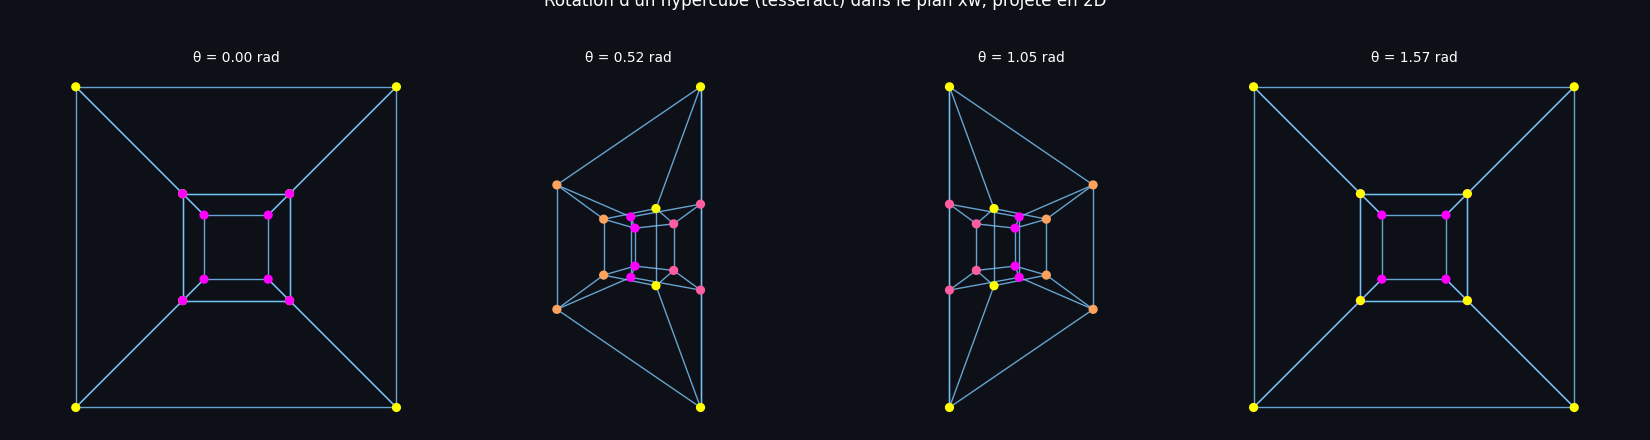

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from itertools import product, combinations

# Les 16 sommets de l'hypercube (tesseract) : toutes les combinaisons de +-1 en 4D
vertices = np.array(list(product([-1,1], repeat=4)), dtype=float)
# Une arête relie deux sommets qui ne diffèrent que sur une seule coordonnée
edges = [(i,j) for i in range(16) for j in range(i+1,16)
         if np.sum(np.abs(vertices[i]-vertices[j])) == 2]

def rotate_4d(v, angle, plane=(0,3)):
    """Rotation dans le plan (x_i, x_j) de l'espace 4D."""
    r = v.copy()
    i, j = plane
    c, s = np.cos(angle), np.sin(angle)
    r[:,i], r[:,j] = v[:,i]*c - v[:,j]*s, v[:,i]*s + v[:,j]*c
    return r

def project_4d_to_2d(v, dist=3.0):
    """Projection en perspective 4D -> 3D -> 2D."""
    w = v[:,3]
    factor3d = dist / (dist - w)
    v3 = v[:,:3] * factor3d[:,None]
    z = v3[:,2]
    factor2d = dist / (dist - z)
    v2 = v3[:,:2] * factor2d[:,None]
    return v2, w

fig, axes = plt.subplots(1, 4, figsize=(15, 4), facecolor="#0d1117")
angles = [0, np.pi/6, np.pi/3, np.pi/2]
for ax, angle in zip(axes, angles):
    ax.set_facecolor("#0d1117")
    rotated = rotate_4d(vertices, angle, plane=(0,3))
    pts2d, w = project_4d_to_2d(rotated)
    for i,j in edges:
        ax.plot([pts2d[i,0], pts2d[j,0]], [pts2d[i,1], pts2d[j,1]], color="#7ec8ff", lw=0.9, alpha=0.8)
    ax.scatter(pts2d[:,0], pts2d[:,1], c=w, cmap="spring", s=25, zorder=3)
    ax.set_aspect("equal")
    ax.set_axis_off()
    ax.set_title(f"θ = {angle:.2f} rad", color="white", fontsize=9)

fig.suptitle("Rotation d'un hypercube (tesseract) dans le plan xw, projeté en 2D", color="white", fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig("out1.png", dpi=110, facecolor=fig.get_facecolor())
print(f"Tesseract : {len(vertices)} sommets, {len(edges)} arêtes (chaque sommet en a 4)")


## 2. L'infini de Cantor : l'argument diagonal <a id="2"></a>

*Infinity and the Mind* (1982) est le grand livre de Rucker sur les infinis de Cantor. L'argument
diagonal (1891) est sa pièce maîtresse : imaginons une liste complète, numérotée, de toutes les suites
infinies de 0 et de 1. On construit alors une nouvelle suite en inversant le n-ième chiffre de la n-ième
suite de la liste — cette nouvelle suite diffère de *chaque* suite de la liste sur au moins une position,
donc elle n'y figure pas. Contradiction : aucune liste ne peut être complète. Il existe donc "plus"
d'infinis de suites binaires que d'entiers naturels.

La suite diagonale (lue en descendant) : 1100101101
La suite anti-diagonale (jamais dans la liste) : 0011010010

Rucker adorait cette preuve dans 'Infinity and the Mind' : elle montre qu'il existe
« plus » de suites binaires infinies que d'entiers -- l'infini de Cantor a des tailles.


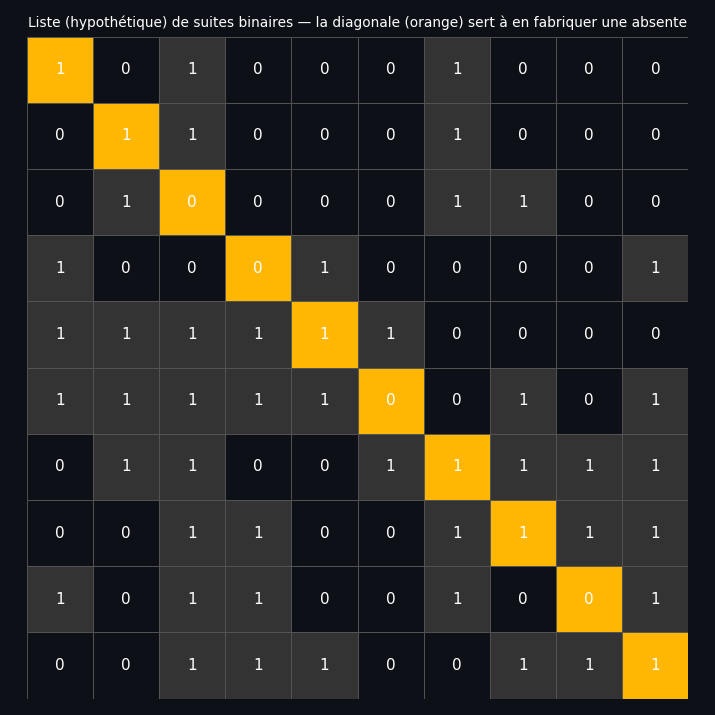

In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import random
random.seed(7)

# Argument diagonal de Cantor : aucune liste de suites binaires infinies ne peut
# être complète. On construit ici une suite qui diffère de la n-ième suite de la
# liste à la n-ième position -- elle ne peut donc figurer nulle part dans la liste.
N = 10
rows = [[random.randint(0,1) for _ in range(N)] for _ in range(N)]
diagonal = [rows[i][i] for i in range(N)]
anti_diagonal = [1 - d for d in diagonal]

print("La suite diagonale (lue en descendant) :", "".join(map(str, diagonal)))
print("La suite anti-diagonale (jamais dans la liste) :", "".join(map(str, anti_diagonal)))
print("\nRucker adorait cette preuve dans 'Infinity and the Mind' : elle montre qu'il existe")
print("« plus » de suites binaires infinies que d'entiers -- l'infini de Cantor a des tailles.")

fig, ax = plt.subplots(figsize=(6.5, 6.5), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
for i in range(N):
    for j in range(N):
        color = "#0d1117"
        if rows[i][j] == 1:
            color = "#333"
        if i == j:
            color = "#ffb703"
        ax.add_patch(plt.Rectangle((j, N-1-i), 1, 1, facecolor=color, edgecolor="#555", linewidth=0.6))
        ax.text(j+0.5, N-1-i+0.5, str(rows[i][j]), color="white", ha="center", va="center", fontsize=10)
ax.set_xlim(0, N); ax.set_ylim(0, N)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Liste (hypothétique) de suites binaires — la diagonale (orange) sert à en fabriquer une absente", color="white", fontsize=9)
plt.tight_layout()
plt.savefig("out2.png", dpi=110, facecolor=fig.get_facecolor())


## 3. Automate cellulaire « Brian's Brain » <a id="3"></a>

Rucker a conçu et distribué *CelLab*, un logiciel d'exploration d'automates cellulaires bien au-delà du
Jeu de la vie de Conway. **Brian's Brain** (Brian Silverman) en est un exemple frappant : trois états
(mort, vivant, mourant) et une règle simple font qu'*aucune* configuration ne reste jamais figée — la
grille grouille perpétuellement d'ondes et d'étincelles qui naissent, se propagent et s'éteignent, sans
jamais atteindre d'équilibre.

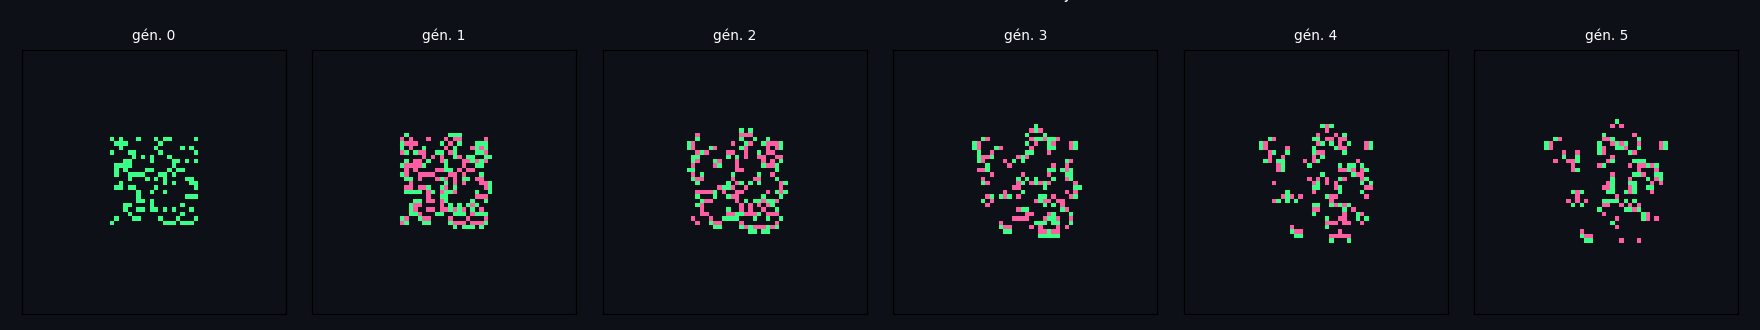

In [3]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(4)

# "Brian's Brain" (Brian Silverman, popularisé par Rucker dans son logiciel CelLab) :
# un automate cellulaire à 3 états -- 0 (mort), 1 (vivant), 2 (mourant).
# Règle : mort -> vivant si exactement 2 voisins vivants ; vivant -> mourant toujours ;
# mourant -> mort toujours. Contrairement au Jeu de la vie, rien ne reste jamais stable :
# le motif est perpétuellement en mouvement, un exemple classique de "vie artificielle" pour Rucker.

SIZE = 60
grid = np.zeros((SIZE, SIZE), dtype=int)
grid[SIZE//2-10:SIZE//2+10, SIZE//2-10:SIZE//2+10] = np.random.choice([0,1], size=(20,20), p=[0.75,0.25])

def step(grid):
    alive = (grid == 1)
    dead = (grid == 0)
    neighbor_count = sum(np.roll(np.roll(alive, dx, axis=0), dy, axis=1)
                          for dx in (-1,0,1) for dy in (-1,0,1) if (dx,dy) != (0,0))
    new_grid = np.zeros_like(grid)
    new_grid[dead & (neighbor_count == 2)] = 1
    new_grid[alive] = 2
    return new_grid

frames = [grid.copy()]
for _ in range(5):
    grid = step(grid)
    frames.append(grid.copy())

fig, axes = plt.subplots(1, 6, figsize=(16, 3), facecolor="#0d1117")
cmap = plt.matplotlib.colors.ListedColormap(["#0d1117", "#39ff88", "#ff5da2"])
for ax, frame, gen in zip(axes, frames, range(6)):
    ax.set_facecolor("#0d1117")
    ax.imshow(frame, cmap=cmap, vmin=0, vmax=2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"gén. {gen}", color="white", fontsize=9)
fig.suptitle("Brian's Brain : vivant (vert) -> mourant (rose) -> mort — jamais stable", color="white", fontsize=11, y=1.05)
plt.tight_layout()
plt.savefig("out3.png", dpi=110, facecolor=fig.get_facecolor())


## 4. Le ruban de Möbius et la bouteille de Klein <a id="4"></a>

Ces surfaces non-orientables reviennent sans cesse dans les écrits de Rucker sur la 4e dimension : un
habitant plat qui parcourrait un ruban de Möbius reviendrait à son point de départ inversé comme dans un
miroir, sans jamais avoir franchi de bord. La bouteille de Klein pousse l'idée plus loin — une surface
fermée, sans intérieur ni extérieur — mais elle ne peut s'immerger dans notre espace 3D qu'au prix d'une
auto-intersection : elle "vit" naturellement en 4 dimensions, où ce croisement disparaît.

Ces deux surfaces sont non-orientables : un habitant 2D qui s'y promène revient
chez lui inversé comme dans un miroir -- sans jamais avoir traversé de bord.


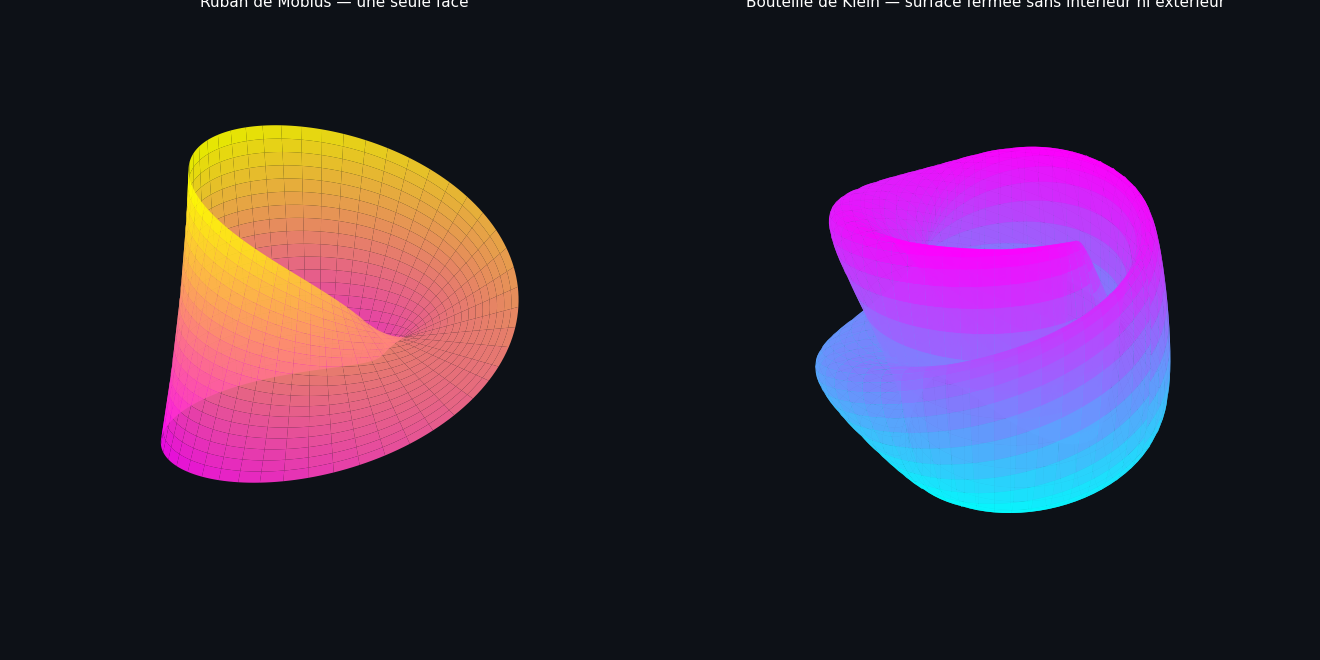

In [4]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Rucker adorait ces surfaces non-orientables dans ses écrits sur la 4e dimension :
# le ruban de Möbius n'a qu'une seule face et un seul bord ; la bouteille de Klein
# pousse l'idée plus loin -- une surface fermée sans intérieur ni extérieur, qui ne
# peut s'immerger sans auto-intersection qu'en 3D (elle vit naturellement en 4D).

fig = plt.figure(figsize=(12, 6), facecolor="#0d1117")

# Ruban de Möbius
ax1 = fig.add_subplot(121, projection="3d")
ax1.set_facecolor("#0d1117")
u = np.linspace(0, 2*np.pi, 200)
v = np.linspace(-0.5, 0.5, 20)
u, v = np.meshgrid(u, v)
x = (1 + v*np.cos(u/2)) * np.cos(u)
y = (1 + v*np.cos(u/2)) * np.sin(u)
z = v * np.sin(u/2)
ax1.plot_surface(x, y, z, cmap="spring", edgecolor="none", alpha=0.9)
ax1.set_axis_off()
ax1.set_title("Ruban de Möbius — une seule face", color="white", fontsize=10)

# Bouteille de Klein (immersion "figure-8")
ax2 = fig.add_subplot(122, projection="3d")
ax2.set_facecolor("#0d1117")
u = np.linspace(0, 2*np.pi, 100)
v = np.linspace(0, 2*np.pi, 100)
u, v = np.meshgrid(u, v)
a = 2.5
x = (a + np.cos(u/2)*np.sin(v) - np.sin(u/2)*np.sin(2*v)) * np.cos(u)
y = (a + np.cos(u/2)*np.sin(v) - np.sin(u/2)*np.sin(2*v)) * np.sin(u)
z = np.sin(u/2)*np.sin(v) + np.cos(u/2)*np.sin(2*v)
ax2.plot_surface(x, y, z, cmap="cool", edgecolor="none", alpha=0.9)
ax2.set_axis_off()
ax2.set_title("Bouteille de Klein — surface fermée sans intérieur ni extérieur", color="white", fontsize=10)

plt.tight_layout()
plt.savefig("out4.png", dpi=110, facecolor=fig.get_facecolor())
print("Ces deux surfaces sont non-orientables : un habitant 2D qui s'y promène revient")
print("chez lui inversé comme dans un miroir -- sans jamais avoir traversé de bord.")


## 5. Le « gnarl » : les classes de complexité de Wolfram <a id="5"></a>

Dans *The Lifebox, the Seashell, and the Soul* (2005), Rucker développe le concept de **gnarl** — sa
propre traduction, plus poétique, de la "classe 4" de Stephen Wolfram : ni l'immobilité stérile de la
classe 1, ni la répétition prévisible de la classe 2, ni le chaos illisible de la classe 3, mais cette
zone frontière où naissent des structures mobiles, persistantes, qui interagissent entre elles — et où,
selon Rucker, se cache la signature même du vivant et du calcul universel.

La règle 110 est démontrée Turing-complète : elle peut en principe simuler n'importe quel calcul.
C'est cette zone frontière -- ni figée ni chaotique -- que Rucker appelle le « gnarl ».


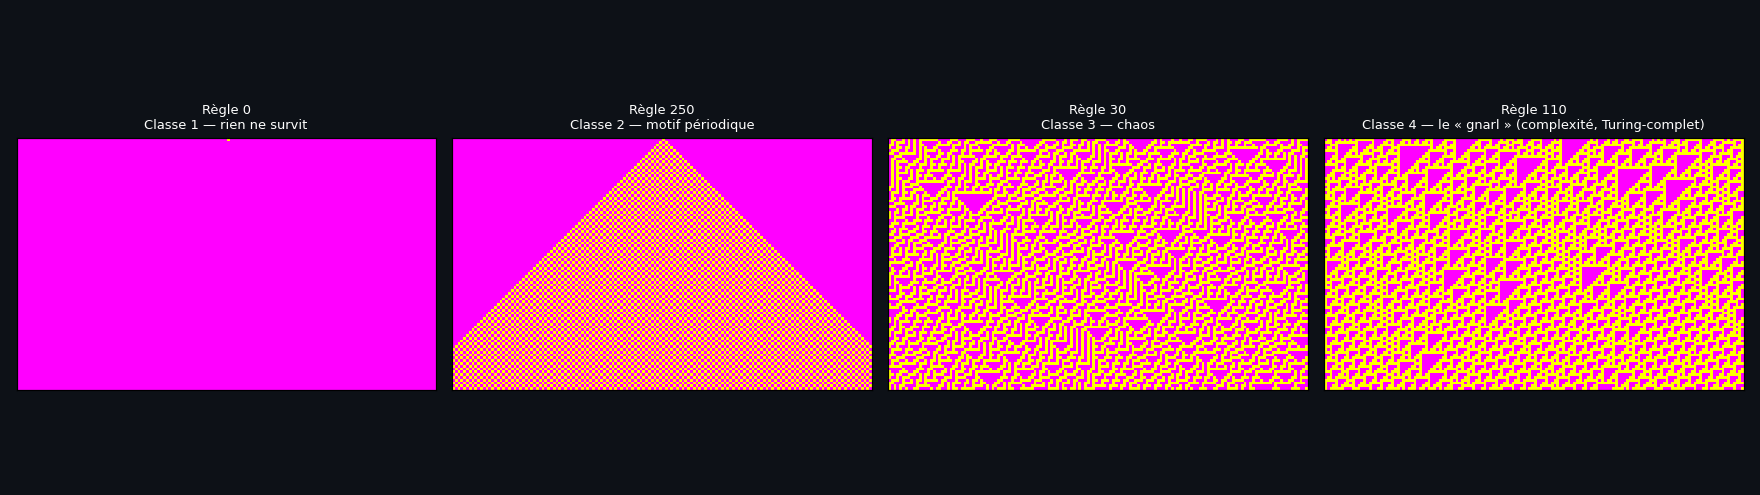

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

# Rucker a popularisé (avec Wolfram) l'idée que les automates cellulaires se
# répartissent en 4 grandes classes de comportement : classe 1 (tout s'éteint),
# classe 2 (motifs périodiques stables), classe 3 (chaos pur, façon bruit),
# classe 4 (le "gnarl" -- ni ordre ni chaos, structures complexes qui se
# déplacent et interagissent : c'est là, selon Rucker, que se cache le vivant).

def elementary_ca(rule, width, steps, seed_row=None):
    grid = np.zeros((steps, width), dtype=int)
    if seed_row is None:
        grid[0, width//2] = 1
    else:
        grid[0] = seed_row
    rule_bits = [(rule >> i) & 1 for i in range(8)]
    for t in range(1, steps):
        for x in range(width):
            l = grid[t-1, (x-1) % width]
            c = grid[t-1, x]
            r = grid[t-1, (x+1) % width]
            idx = l*4 + c*2 + r
            grid[t, x] = rule_bits[idx]
    return grid

W, STEPS = 150, 90
np.random.seed(2)
random_seed_row = np.random.randint(0, 2, W)

rules = [(0,  "Classe 1 — rien ne survit"),
         (250, "Classe 2 — motif périodique"),
         (30,  "Classe 3 — chaos"),
         (110, "Classe 4 — le « gnarl » (complexité, Turing-complet)")]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.5), facecolor="#0d1117")
for ax, (rule, label) in zip(axes, rules):
    ax.set_facecolor("#0d1117")
    seed = random_seed_row if rule in (30, 110) else None
    grid = elementary_ca(rule, W, STEPS, seed_row=seed)
    ax.imshow(grid, cmap="spring", interpolation="nearest")
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"Règle {rule}\n{label}", color="white", fontsize=8.5)

fig.suptitle("Les quatre classes de comportement des automates cellulaires (Wolfram / Rucker)", color="white", fontsize=11, y=1.04)
plt.tight_layout()
plt.savefig("out5.png", dpi=110, facecolor=fig.get_facecolor())
print("La règle 110 est démontrée Turing-complète : elle peut en principe simuler n'importe quel calcul.")
print("C'est cette zone frontière -- ni figée ni chaotique -- que Rucker appelle le « gnarl ».")


## 6. La projection stéréographique <a id="6"></a>

Outil récurrent de *The Fourth Dimension* : projeter une sphère sur un plan depuis son pôle Nord permet
d'"aplatir" un objet courbe en préservant les angles et les cercles (une propriété dite conforme). Rucker
s'en sert comme tremplin d'intuition : le même procédé, appliqué une dimension plus haut, permet de se
représenter une hypersphère (3-sphère) comme un espace 3D ordinaire, avec l'infini ramené à un seul point
ajouté — exactement comme le pôle Nord devient le "point à l'infini" du plan projeté.

Le pôle Nord (point de projection) part à l'infini sur le plan :
c'est exactement ce tour de passe-passe que Rucker réutilise pour visualiser l'hypersphère.


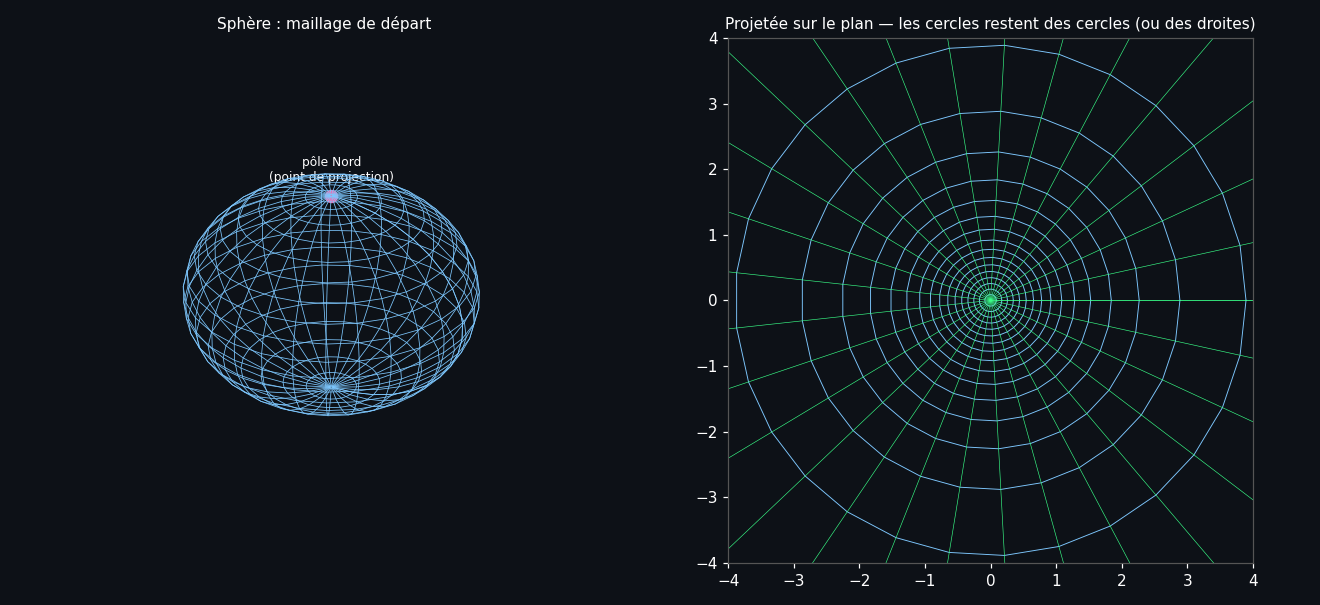

In [6]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Rucker utilise la projection stéréographique dans "The Fourth Dimension" comme
# passerelle d'intuition : c'est l'outil qui permet d'"aplatir" une sphère sur un
# plan (comme une carte du monde), et le même principe, appliqué une dimension
# plus haut, permet de se représenter une hypersphère (3-sphère) comme un espace
# 3D ordinaire -- avec l'infini ramené à un seul point.

fig = plt.figure(figsize=(12, 5.5), facecolor="#0d1117")

# Sphère avec un maillage de méridiens/parallèles
ax1 = fig.add_subplot(121, projection="3d")
ax1.set_facecolor("#0d1117")
u = np.linspace(0, 2*np.pi, 30)
v = np.linspace(0.01, np.pi-0.01, 20)
U, V = np.meshgrid(u, v)
X = np.sin(V)*np.cos(U)
Y = np.sin(V)*np.sin(U)
Z = np.cos(V)
ax1.plot_wireframe(X, Y, Z, color="#7ec8ff", linewidth=0.5)
ax1.scatter([0],[0],[1], color="#ff5da2", s=60)
ax1.text(0,0,1.15,"pôle Nord\n(point de projection)", color="white", fontsize=8, ha="center")
ax1.set_axis_off()
ax1.set_title("Sphère : maillage de départ", color="white", fontsize=10)

# Projection stéréographique depuis le pôle nord vers le plan z=-1
ax2 = fig.add_subplot(122)
ax2.set_facecolor("#0d1117")
def stereo_project(x, y, z):
    denom = 1 - z
    denom = np.where(np.abs(denom) < 1e-6, 1e-6, denom)
    return x/denom, y/denom

for i in range(len(v)):
    px, py = stereo_project(X[i], Y[i], Z[i])
    ax2.plot(px, py, color="#7ec8ff", lw=0.6)
for j in range(len(u)):
    px, py = stereo_project(X[:,j], Y[:,j], Z[:,j])
    ax2.plot(px, py, color="#39ff88", lw=0.4)
ax2.set_xlim(-4,4); ax2.set_ylim(-4,4)
ax2.set_aspect("equal")
ax2.set_facecolor("#0d1117")
ax2.tick_params(colors="white")
for spine in ax2.spines.values(): spine.set_color("#555")
ax2.set_title("Projetée sur le plan — les cercles restent des cercles (ou des droites)", color="white", fontsize=10)

plt.tight_layout()
plt.savefig("out6.png", dpi=110, facecolor=fig.get_facecolor())
print("Le pôle Nord (point de projection) part à l'infini sur le plan :")
print("c'est exactement ce tour de passe-passe que Rucker réutilise pour visualiser l'hypersphère.")


## 7. Vie artificielle : essaims et comportement émergent (boids) <a id="7"></a>

Rucker s'est passionné pour la vie artificielle comme extension naturelle de ses travaux sur les
automates cellulaires : des règles purement locales et individuelles peuvent engendrer un comportement
collectif qui *semble* concerté, sans qu'aucun agent n'ait la moindre vue d'ensemble. Le modèle "boids"
de Craig Reynolds (1986) — séparation, alignement, cohésion — en est l'exemple canonique, souvent cité
comme illustration de ce que Rucker appelle l'émergence.

Aucun agent n'a de vue d'ensemble : le vol groupé émerge de règles purement locales.


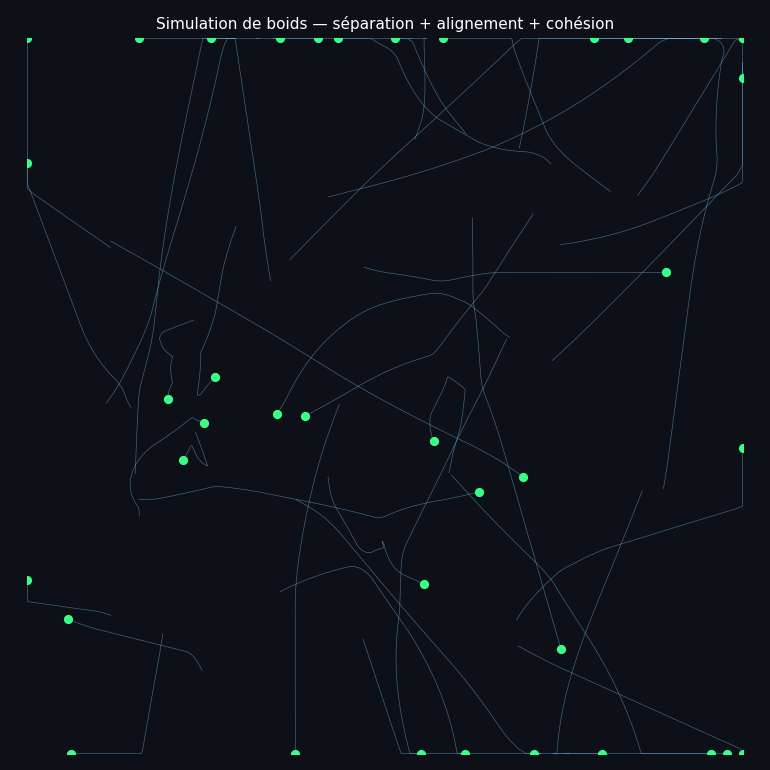

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(11)

# Rucker s'est beaucoup intéressé à la vie artificielle : des règles locales très
# simples (répulsion de courte portée, alignement, cohésion) suffisent à produire
# un comportement de groupe qui semble "intentionnel" -- sans le moindre chef
# d'orchestre. Modèle "boids" de Craig Reynolds (1986), simulation minimaliste.

N = 40
pos = np.random.uniform(-1, 1, (N, 2)) * 20
vel = np.random.uniform(-1, 1, (N, 2))

def step(pos, vel, dt=1.0):
    new_vel = vel.copy()
    for i in range(N):
        diff = pos - pos[i]
        dist = np.linalg.norm(diff, axis=1)
        dist[i] = np.inf

        # séparation : s'éloigner des trop proches voisins
        close = dist < 2.0
        sep = -diff[close].sum(axis=0) if close.any() else np.zeros(2)

        # alignement : adopter la vitesse moyenne du voisinage
        near = dist < 6.0
        align = vel[near].mean(axis=0) - vel[i] if near.any() else np.zeros(2)

        # cohésion : se rapprocher du centre de masse du voisinage
        cohesion = (pos[near].mean(axis=0) - pos[i]) if near.any() else np.zeros(2)

        new_vel[i] += 0.05*sep + 0.02*align + 0.002*cohesion
        speed = np.linalg.norm(new_vel[i])
        if speed > 1.5:
            new_vel[i] = new_vel[i] / speed * 1.5
    new_pos = pos + new_vel * dt
    new_pos = np.clip(new_pos, -25, 25)
    return new_pos, new_vel

trail = [pos.copy()]
for _ in range(60):
    pos, vel = step(pos, vel)
    trail.append(pos.copy())

fig, ax = plt.subplots(figsize=(7, 7), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
trail = np.array(trail)  # (steps, N, 2)
for i in range(N):
    ax.plot(trail[:,i,0], trail[:,i,1], color="#7ec8ff", lw=0.4, alpha=0.5)
ax.scatter(trail[-1,:,0], trail[-1,:,1], color="#39ff88", s=25, zorder=3)
ax.set_xlim(-25,25); ax.set_ylim(-25,25)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Simulation de boids — séparation + alignement + cohésion", color="white", fontsize=10)
plt.tight_layout()
plt.savefig("out7.png", dpi=110, facecolor=fig.get_facecolor())
print("Aucun agent n'a de vue d'ensemble : le vol groupé émerge de règles purement locales.")


## 8. Le tapis de Sierpinski et l'éponge de Menger <a id="8"></a>

*Mind Tools* (1987) consacre un chapitre entier aux fractales comme "outils de pensée". Le tapis de
Sierpinski (retirer indéfiniment le carré central d'un pavage 3×3) et son cousin en trois dimensions,
l'éponge de Menger (retirer les cubes centraux d'un pavage 3×3×3), donnent des objets dont la dimension
fractale n'est ni 2 ni 3 — une notion que Rucker trouvait particulièrement vertigineuse pour des formes
que l'on peut pourtant tenir dans la main (ou presque).

Tapis de Sierpinski : 4096 carrés à l'itération 4, dimension fractale ≈ 1.8928
Éponge de Menger : 400 cubes à l'itération 2, dimension fractale ≈ 2.7268


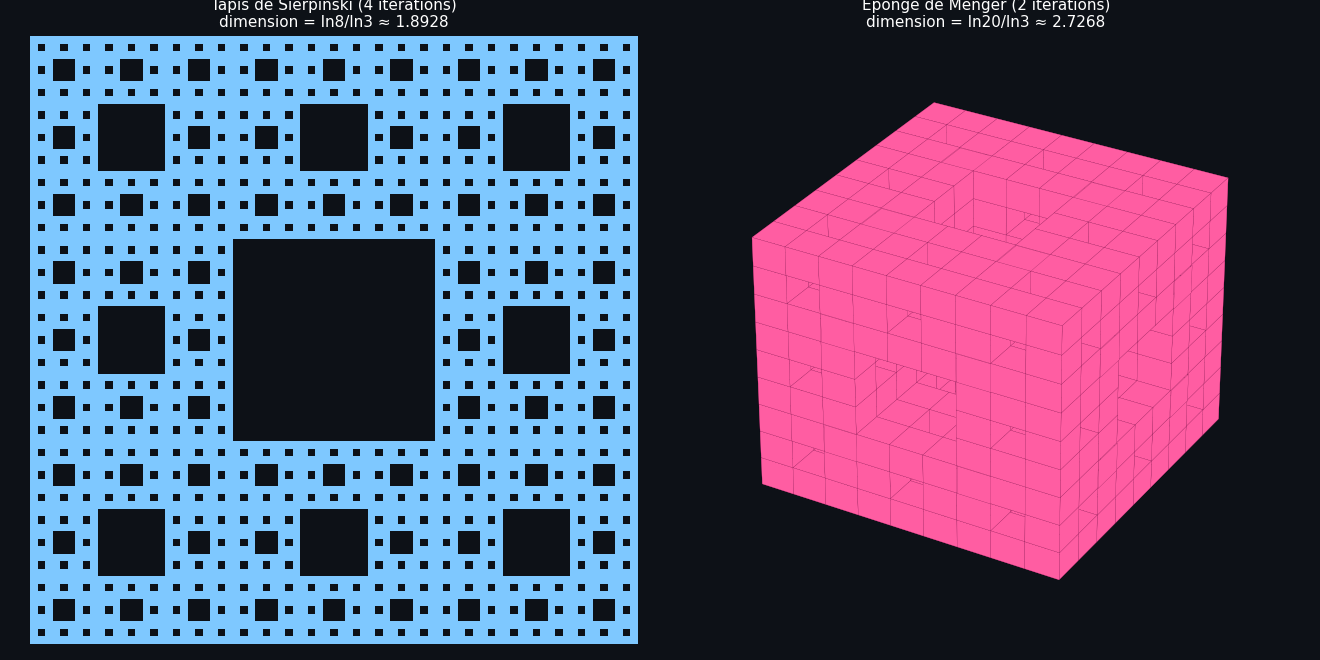

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import math

# Rucker consacre un chapitre de "Mind Tools" aux objets fractals. Le tapis de
# Sierpinski (2D) et son cousin en 3D, l'éponge de Menger, se construisent en
# retirant indéfiniment le "tiers central" d'un carré, puis d'un cube.

def sierpinski_carpet(ax, x, y, size, depth):
    if depth == 0:
        ax.add_patch(plt.Rectangle((x, y), size, size, facecolor="#7ec8ff", edgecolor="none"))
        return
    s = size / 3
    for i in range(3):
        for j in range(3):
            if i == 1 and j == 1:
                continue
            sierpinski_carpet(ax, x + i*s, y + j*s, s, depth-1)

fig = plt.figure(figsize=(12, 6), facecolor="#0d1117")

ax1 = fig.add_subplot(121)
ax1.set_facecolor("#0d1117")
sierpinski_carpet(ax1, 0, 0, 1, 4)
ax1.set_xlim(0,1); ax1.set_ylim(0,1)
ax1.set_aspect("equal"); ax1.set_axis_off()
dim2 = math.log(8)/math.log(3)
ax1.set_title(f"Tapis de Sierpinski (4 itérations)\ndimension = ln8/ln3 ≈ {dim2:.4f}", color="white", fontsize=10)

def menger_cubes(depth):
    cubes = [(0,0,0)]
    size = 1
    for _ in range(depth):
        new_cubes = []
        for (x,y,z) in cubes:
            for i in range(3):
                for j in range(3):
                    for k in range(3):
                        holes = sum(c == 1 for c in (i,j,k))
                        if holes >= 2:
                            continue
                        new_cubes.append((x*3+i, y*3+j, z*3+k))
        cubes = new_cubes
        size *= 3
    return cubes, size

cubes, size = menger_cubes(2)
voxel_grid = np.zeros((size, size, size), dtype=bool)
for (x,y,z) in cubes:
    voxel_grid[x,y,z] = True

ax2 = fig.add_subplot(122, projection="3d")
ax2.set_facecolor("#0d1117")
ax2.voxels(voxel_grid, facecolor="#ff5da2", edgecolor="#550033", linewidth=0.1)
ax2.set_axis_off()
dim3 = math.log(20)/math.log(3)
ax2.set_title(f"Éponge de Menger (2 itérations)\ndimension = ln20/ln3 ≈ {dim3:.4f}", color="white", fontsize=10)

plt.tight_layout()
plt.savefig("out8.png", dpi=110, facecolor=fig.get_facecolor())
print(f"Tapis de Sierpinski : {8**4} carrés à l'itération 4, dimension fractale ≈ {dim2:.4f}")
print(f"Éponge de Menger : {len(cubes)} cubes à l'itération 2, dimension fractale ≈ {dim3:.4f}")


## 9. Bac à sable interactif <a id="9"></a>

Pour la démo live : un slider `ipywidgets` pour faire tourner le tesseract à l'angle de son choix, et un
second pour relancer Brian's Brain pendant un nombre de générations ajustable et regarder le motif
grouiller indéfiniment. Idéal pour montrer qu'un notebook Jupyter est un vrai labo interactif, pas juste
un exécuteur de scripts.

> ⚠️ Nécessite `ipywidgets` installé et activé dans l'environnement JupyterLab (`pip install ipywidgets`).

In [ ]:
from ipywidgets import interact, FloatSlider, IntSlider
import matplotlib.pyplot as plt
import numpy as np
from itertools import product

vertices = np.array(list(product([-1,1], repeat=4)), dtype=float)
edges = [(i,j) for i in range(16) for j in range(i+1,16)
         if np.sum(np.abs(vertices[i]-vertices[j])) == 2]

def rotate_4d(v, angle, plane=(0,3)):
    r = v.copy()
    i, j = plane
    c, s = np.cos(angle), np.sin(angle)
    r[:,i], r[:,j] = v[:,i]*c - v[:,j]*s, v[:,i]*s + v[:,j]*c
    return r

def project_4d_to_2d(v, dist=3.0):
    w = v[:,3]
    factor3d = dist / (dist - w)
    v3 = v[:,:3] * factor3d[:,None]
    z = v3[:,2]
    factor2d = dist / (dist - z)
    return v3[:,:2] * factor2d[:,None], w

def show_tesseract(theta=0.0):
    rotated = rotate_4d(vertices, theta, plane=(0,3))
    pts2d, w = project_4d_to_2d(rotated)
    fig, ax = plt.subplots(figsize=(5, 5), facecolor="#0d1117")
    ax.set_facecolor("#0d1117")
    for i, j in edges:
        ax.plot([pts2d[i,0], pts2d[j,0]], [pts2d[i,1], pts2d[j,1]], color="#7ec8ff", lw=0.9)
    ax.scatter(pts2d[:,0], pts2d[:,1], c=w, cmap="spring", s=30)
    ax.set_aspect("equal"); ax.set_axis_off()
    ax.set_title(f"Tesseract, θ = {theta:.2f} rad", color="white")
    plt.show()

def brians_brain(generations=5):
    np.random.seed(4)
    SIZE = 60
    grid = np.zeros((SIZE, SIZE), dtype=int)
    grid[25:35, 25:35] = np.random.choice([0,1], size=(10,10), p=[0.75,0.25])
    def step(g):
        alive = (g == 1); dead = (g == 0)
        nc = sum(np.roll(np.roll(alive, dx, 0), dy, 1)
                 for dx in (-1,0,1) for dy in (-1,0,1) if (dx,dy)!=(0,0))
        ng = np.zeros_like(g)
        ng[dead & (nc==2)] = 1
        ng[alive] = 2
        return ng
    for _ in range(generations):
        grid = step(grid)
    cmap = plt.matplotlib.colors.ListedColormap(["#0d1117", "#39ff88", "#ff5da2"])
    fig, ax = plt.subplots(figsize=(5,5), facecolor="#0d1117")
    ax.imshow(grid, cmap=cmap, vmin=0, vmax=2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f"Brian's Brain, génération {generations}", color="white")
    plt.show()

interact(show_tesseract, theta=FloatSlider(0.0, min=0, max=2*np.pi, step=0.1))
interact(brians_brain, generations=IntSlider(5, min=0, max=60, step=1))


## Pour aller plus loin

Quelques pistes de lecture pour prolonger la démo :

- **Rudy Rucker**, *The Fourth Dimension* (1984) — voir et penser en 4D
- **Rudy Rucker**, *Infinity and the Mind* (1982) — Cantor, Gödel, les infinis
- **Rudy Rucker**, *Mind Tools* (1987) — fractales, information, logique comme "outils de pensée"
- **Rudy Rucker**, *The Lifebox, the Seashell, and the Soul* (2005) — computation, gnarl, vie artificielle
- Logiciel **CelLab** (Rucker & John Walker) — laboratoire d'automates cellulaires
- Série de romans **Continuum** (*White Light*, *Spaceland*...) — la 4e dimension en fiction

---
*Notebook généré pour une démo JupyterLab, en écho aux notebooks Gardner, Pickover, Stewart, Delahaye et
du Sautoy — libre à toi de piocher, couper, ou dupliquer les cellules selon le public visé.*
